In [28]:
import geopandas as gpd 

# Path to the .gdb.zip file
parent_dir = "./"

name_file = '20230828_VectorFlatFileGDB.gdb.zip'

zip_file_path = parent_dir + name_file

# Add `zip://` prefix to read directly from the zipped file
zip_gdb_path = f"zip://{zip_file_path}"

# List all layers in the Geodatabase (optional step)
import fiona
layers = fiona.listlayers(zip_gdb_path)
print(f"Available layers: {layers}")

# Read a specific layer from the zipped GDB file
gdf = gpd.read_file(zip_gdb_path, layer=layers[0])

# Convert to Pandas DataFrame (optional if you don't need geometries)
#df = gdf.drop(columns='geometry')  # Only if you want non-geospatial data
gdf.head()

Available layers: ['Output']


,ID,VectorSpeciesName,VectorSpeciesName_,LocationCode,LocationName,LocationParentCode,LocationType,CountryCode,VectorSpeciesCode,VectorCategoryCode,AssessedDistributionStatus,LayerToMap,ValidFrom,ValidTo,DateSelected,Date_Folder_Path,Date_Map_Title,SHAPE_Length,SHAPE_Area,geometry
0,{4DFE3DAF-3576-48E1-8D8B-1B9DC9AF6D25},Aedes invasive mosquitoes,GR_Aedes_invasive_mosquitoes,UKM91,Scottish Borders,UKM9,None,UK,None,None,INV003A,1,None,20230828092525.4886256,20230828,2023_08,August 2023,3.867355,0.661639,"MULTIPOLYGON (((-2.03433 55.81116, -2.09375 55..."
1,{E1A34BA7-D48A-4C4E-BFE8-CEE646D584D6},Aedes invasive mosquitoes,GR_Aedes_invasive_mosquitoes,UKM91,Scottish Borders,UKM9,None,UK,None,None,INV003A,1,None,20230828092525.4886256,20230828,2023_08,August 2023,3.867355,0.661639,"MULTIPOLYGON (((-2.03433 55.81116, -2.09375 55..."
2,{3CC4C867-88BF-4D95-97DE-2AC510AF6B5B},Aedes invasive mosquitoes,GR_Aedes_invasive_mosquitoes,UKM71,Angus and Dundee City,UKM7,None,UK,None,None,INV003A,1,None,20230828092512.2159879,20230828,2023_08,August 2023,2.365517,0.307359,"MULTIPOLYGON (((-2.42535 56.75519, -2.58436 56..."
3,{655636C2-6B69-464F-A9BF-E94C8622EAE3},Aedes invasive mosquitoes,GR_Aedes_invasive_mosquitoes,UKM71,Angus and Dundee City,UKM7,None,UK,None,None,INV003A,1,None,20230828092512.2159879,20230828,2023_08,August 2023,2.365517,0.307359,"MULTIPOLYGON (((-2.42535 56.75519, -2.58436 56..."
4,{22267C28-A2AB-4A22-8FEA-1491A2B5B5DF},Aedes invasive mosquitoes,GR_Aedes_invasive_mosquitoes,UKM94,South Ayrshire,UKM9,None,UK,None,None,INV003A,1,None,20230828092512.8388279,20230828,2023_08,August 2023,2.045732,0.160745,"MULTIPOLYGON (((-4.46187 55.1703, -4.66145 55...."


In [29]:
# INV001AInvasive - Established
# INV002AInvasive - Introduced
# INV003AInvasive - Absent
# INV004AInvasive - No data
# INV999AInvasive - Unknown
# NAT001ANative - Present
# NAT002ANative - Antic. Absent
# NAT003ANative - Obs. Absent
# NAT004ANative - No data
# NAT005ANative - Introduced
# NAT999ANative - Unknown

code_to_status = {
    'INV001A': 'Established',
    'INV002A': 'Introduced',
    'INV003A': 'Absent',
    'INV004A': 'No data',
    'INV999A': 'Unknown',
    'NAT001A': 'Present',
    'NAT002A': 'Absent',
    'NAT003A': 'Absent',
    'NAT004A': 'No data',
    'NAT005A': 'Introduced',
    'NAT999A': 'Unknown'
}

# Replace 'AssessedDistributionCode' with the actual column name
gdf['status'] = gdf['AssessedDistributionStatus'].map(code_to_status)


In [30]:
mosquitoes = gdf[gdf['VectorCategoryCode'] == 'Mosq']

In [31]:
mosquitoes["VectorSpeciesCode"].unique()

array(['VECT-000363-A', 'VECT-000443-A', 'VECT-000429-A', 'VECT-000446-A',
       'VECT-000431-A', 'VECT-000441-A', 'VECT-000444-A', 'VECT-000361-A',
       'VECT-000396-A', 'VECT-000430-A', 'VECT-000372-A',
       'VECT-0004816-A', 'VECT-000373-A'], dtype=object)

<Axes: >

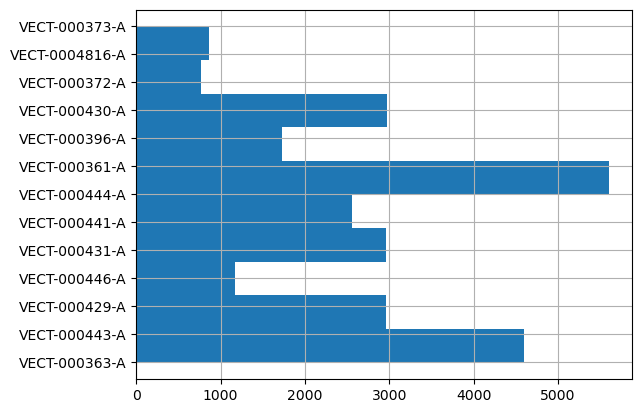

In [32]:
mosquitoes["VectorSpeciesCode"].hist(orientation='horizontal')

<Axes: >

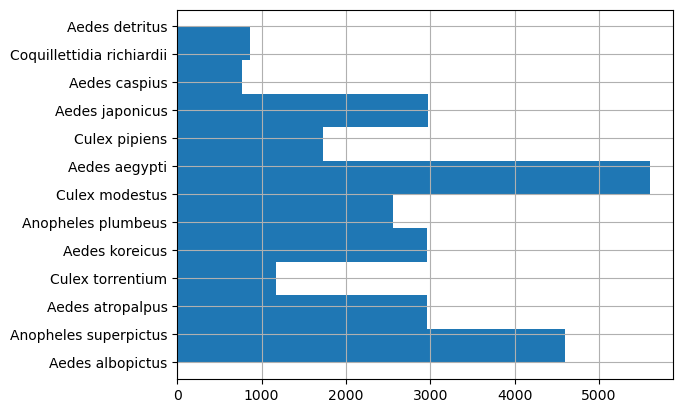

In [33]:
mosquitoes["VectorSpeciesName"].hist(orientation='horizontal')

In [34]:
species_mapping = dict(zip(mosquitoes['VectorSpeciesCode'], mosquitoes['VectorSpeciesName']))
print(species_mapping)

{'VECT-000363-A': 'Aedes albopictus', 'VECT-000443-A': 'Anopheles superpictus', 'VECT-000429-A': 'Aedes atropalpus', 'VECT-000446-A': 'Culex torrentium', 'VECT-000431-A': 'Aedes koreicus', 'VECT-000441-A': 'Anopheles plumbeus', 'VECT-000444-A': 'Culex modestus', 'VECT-000361-A': 'Aedes aegypti', 'VECT-000396-A': 'Culex pipiens', 'VECT-000430-A': 'Aedes japonicus', 'VECT-000372-A': 'Aedes caspius', 'VECT-0004816-A': 'Coquillettidia richiardii', 'VECT-000373-A': 'Aedes detritus'}


In [35]:
aedes_mosquitoes = mosquitoes[mosquitoes['VectorSpeciesName'].str.contains('aedes', case=False, na=False)]

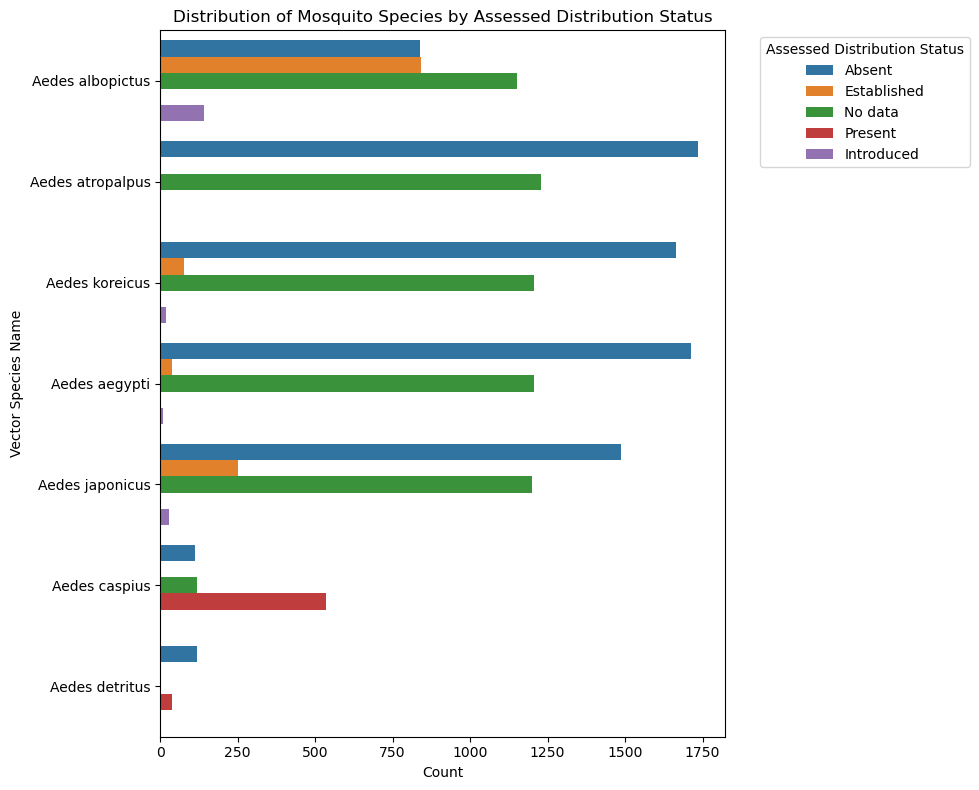

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 8))

# Create a horizontal count plot
sns.countplot(y='VectorSpeciesName', hue='status', data=aedes_mosquitoes)

plt.xlabel('Count')
plt.ylabel('Vector Species Name')
plt.title('Distribution of Mosquito Species by Assessed Distribution Status')
plt.legend(title='Assessed Distribution Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
#Convert to GeoDataFrame
import geopandas as gpd
from shapely import wkt

gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

In [12]:
# Import file .tif of world clim to use as reference

import rasterio

# Open the reference raster to get CRS and transform
# Define file paths
parent_dir = "/eos/jeodpp/data/projects/ETOHA/DATA/"
dir_world_clim = "ClimateData/WorldClim_data/"
parent_dir = "./"
dir_world_clim = "world_clim/"
#parent_dir = "../../"
#dir_world_clim = "climate/world_clim/wc2.1_30s_tavg/"

raster_file = parent_dir + dir_world_clim + 'wc2.1_30s_tavg_01.tif'

with rasterio.open(raster_file) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_width = src.width
    raster_height = src.height

# Set the CRS of the GeoDataFrame (if not already set)
# Replace 'EPSG:4326' with the appropriate CRS if known
gdf.crs = gdf.crs or 'EPSG:4326'

# Reproject GeoDataFrame to match raster CRS
gdf = gdf.to_crs(raster_crs)

In [13]:
gdf['status'].unique()

array(['Absent', 'Unknown', 'Present', 'No data', 'Introduced',
       'Established'], dtype=object)

In [26]:
gdf.columns

Index(['ID', 'VectorSpeciesName', 'VectorSpeciesName_', 'LocationCode',
       'LocationName', 'LocationParentCode', 'LocationType', 'CountryCode',
       'VectorSpeciesCode', 'VectorCategoryCode', 'AssessedDistributionStatus',
       'LayerToMap', 'ValidFrom', 'ValidTo', 'DateSelected',
       'Date_Folder_Path', 'Date_Map_Title', 'SHAPE_Length', 'SHAPE_Area',
       'geometry', 'status'],
      dtype='object')

In [27]:
gdf["VectorSpeciesName"].unique()

array(['Aedes invasive mosquitoes', 'Rhipicephalus sanguineus group',
       'Anopheles maculipennis s.l. of medical importance',
       'Ornithodoros spp.', 'Anopheles maculipennis s.l. (complex)',
       'Aedes vexans s.l.', 'Culex pipiens group',
       'Culicoides obsoletus/scoticus', 'Anopheles claviger s.l.',
       'Culicoides pulicaris/Culicoides lupicaris',
       'Culicoides punctatus s.l.', 'Culicoides newsteadi s.l.',
       'Aedes detritus/coluzzii', 'Aedes cinereus/geminus',
       'Culex perexiguus/univittatus', 'Aedes annulipes/cantans',
       'Phlebotomus perfiliewi', 'Aedes albopictus',
       'Phlebotomus alexandri', 'Anopheles superpictus',
       'Phlebotomus mascittii', 'Culicoides imicola',
       'Dermacentor reticulatus', 'Ixodes persulcatus',
       'Aedes atropalpus', 'Culex torrentium', 'Phlebotomus tobbi',
       'Aedes koreicus', 'Anopheles plumbeus', 'Culex modestus',
       'Phlebotomus papatasi', 'Phlebotomus sergenti', 'Aedes aegypti',
       'Phlebot

In [38]:
from rasterio.features import rasterize
import numpy as np

# Define the output shape and transform based on the reference raster
out_shape = (raster_height, raster_width)
out_transform = raster_transform

# Ensure 'presence' column is in the correct format (1 for presence, 0 for absence)
# Adjust this mapping based on your actual data
gdf['presence_numeric'] = gdf['status'].map({'Absent': 0, 'Present': 1, "Established":1, 'No data': 3, "Introduced":2, "Unknown":3})

gdf_albo = gdf[gdf['VectorSpeciesName'].str.contains('albo', case=False, na=False)]

np.int64(2970)

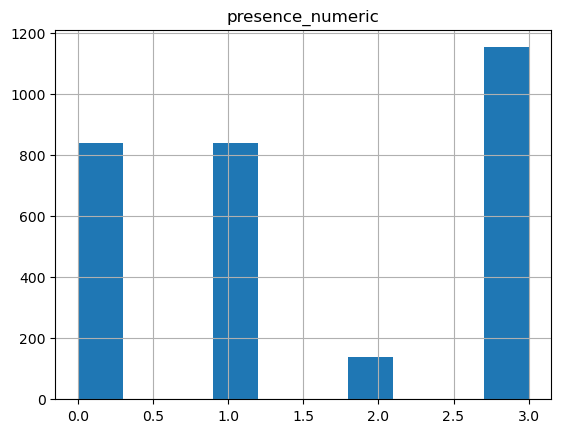

In [39]:
gdf_albo.hist(column='presence_numeric')
gdf_albo["status"].count()

/tmp/ipykernel_36526/563950038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='status', data=gdf_albo, palette='viridis')


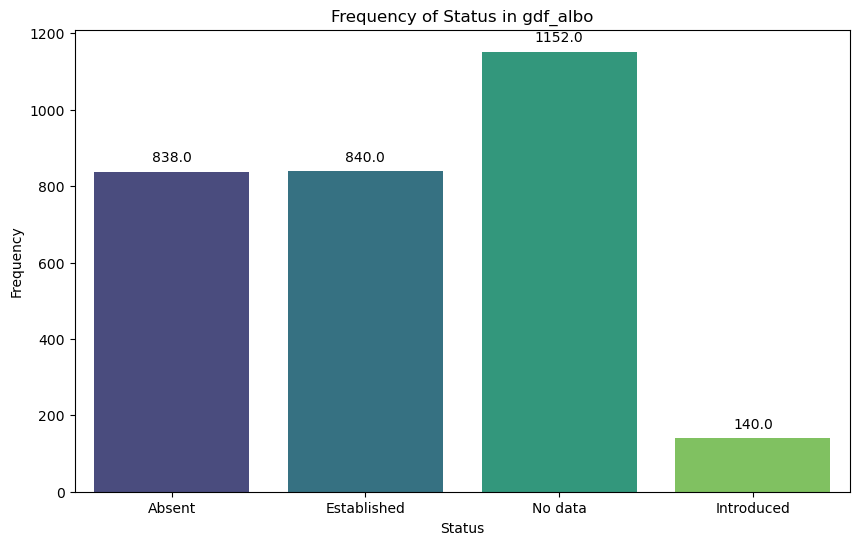

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a count plot for the 'status' column
ax = sns.countplot(x='status', data=gdf_albo, palette='viridis')

# Add titles and labels
plt.title('Frequency of Status in gdf_albo')
plt.xlabel('Status')
plt.ylabel('Frequency')

# Add count labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Show the plot
plt.show()

In [41]:
gdf_albo['LocationCode']

24028       UKM50
24029       UKM50
24114       UKM78
24115       UKM78
24124       UKM92
           ...   
79947    GEG11304
79948    SYG12842
79949    SYG12842
79968        CH01
79969        CH01
Name: LocationCode, Length: 2970, dtype: object

<Axes: >

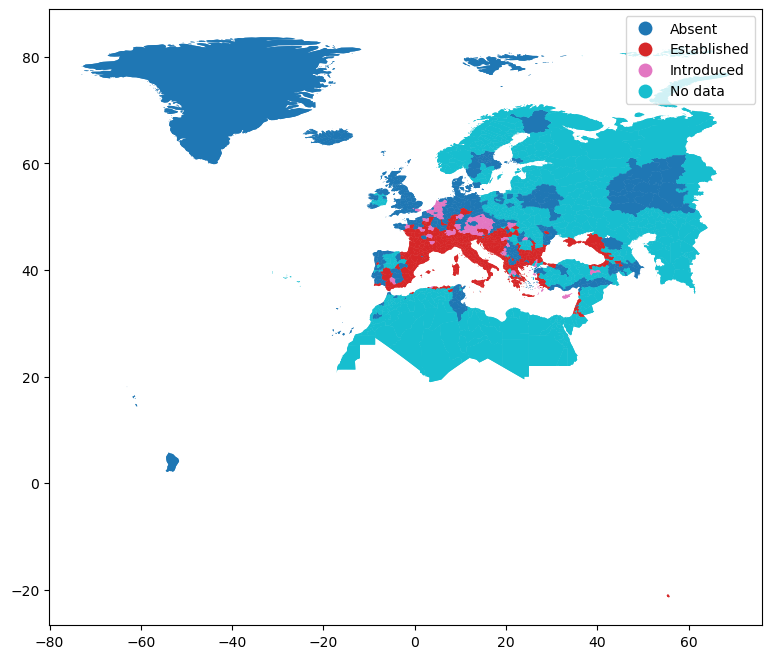

In [42]:
gdf_albo.plot(column='status', legend=True, figsize=(10, 8))

In [43]:
# Prepare the shapes and values and write the presence/absence records in a new raster file

shapes = ((geom, value) for geom, value in zip(gdf_albo.geometry, gdf_albo['presence_numeric']))
# Create an empty raster array initialized with 0 (absence)
raster = np.zeros(out_shape, dtype=np.uint8)

# Rasterize the geometries
raster = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=out_transform,
    fill=4,            # Value for pixels not covered by any geometry
    all_touched=True,  # Include all pixels touched by geometries
    dtype=rasterio.uint8
)
#parent_dir = "/eos/jeodpp/data/projects/ETOHA/DATA/VectorData/mosquitoes/GeoPortal ECDC/"
parent_dir = "."

with rasterio.open(
    parent_dir + 'albopictus_ecdc_as_WorldClim_raster.tif',
    'w',
    driver='GTiff',
    height=out_shape[0],
    width=out_shape[1],
    count=1,
    dtype=rasterio.uint8,
    crs=raster_crs,
    transform=out_transform,
) as dst:
    dst.write(raster, 1)

In [44]:
import numpy as np
import rasterio
from rasterio.features import rasterize

# Create a dictionary mapping LocationCode to unique integer values
unique_codes = gdf_albo['LocationCode'].unique()
code_map = {code: idx for idx, code in enumerate(unique_codes, start=1)}

# Prepare the shapes with integer codes instead of presence/absence
shapes = ((geom, code_map[loc_code]) for geom, loc_code in zip(gdf_albo.geometry, gdf_albo['LocationCode']))

# Create an empty raster array initialized with a no-data value (e.g., 0)
raster = np.zeros(out_shape, dtype=np.uint8)

# Rasterize the geometries with LocationCode values
raster = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=out_transform,
    fill=0,            # No-data value
    all_touched=True,  # Include all pixels touched by geometries
    dtype=rasterio.uint16
)

# Save the raster with integer values representing LocationCodes
output_path = parent_dir + 'albopictus_ecdc_NUTS3_location_codes.tif'
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=out_shape[0],
    width=out_shape[1],
    count=1,
    dtype=rasterio.uint16,
    crs=raster_crs,
    transform=out_transform,
) as dst:
    dst.write(raster, 1)

# Save the lookup table as a CSV or dictionary for reference
import pandas as pd
lookup_table = pd.DataFrame(list(code_map.items()), columns=['LocationCode', 'RasterValue'])
lookup_table.to_csv(parent_dir + 'location_code_lookup.csv', index=False)


/home/biazzin/conda-envs/climate_env/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


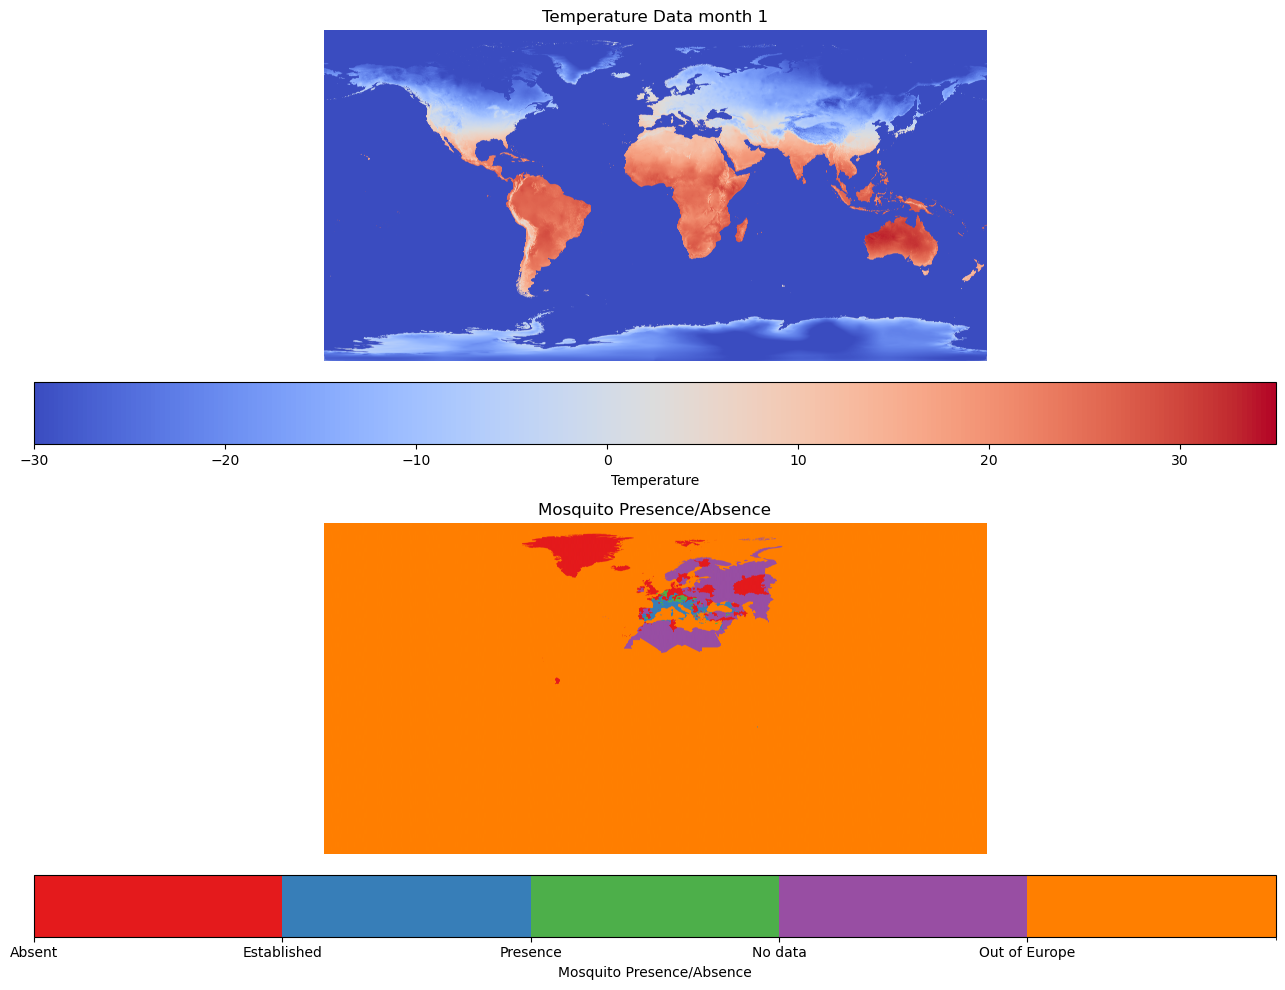

In [45]:
import rasterio

import matplotlib.pyplot as plt

# Open both rasters
with rasterio.open(raster_file) as temp_src, rasterio.open(parent_dir + 'albopictus_ecdc_as_WorldClim_raster.tif') as mosq_src:
    temp_data = temp_src.read(1)
    mosq_data = mosq_src.read(1)

fig, axs = plt.subplots(2, 1, figsize=(20, 10))
temp_plot = axs[0].imshow(temp_data, cmap='coolwarm', vmin=-30, vmax = 35)
axs[0].set_title('Temperature Data month 1')
axs[0].axis('off')
plt.colorbar(temp_plot, orientation='horizontal', pad=0.05, label='Temperature')

import matplotlib.colors as mcolors

# Define custom colormap for mosquito presence categories
cmap = mcolors.ListedColormap(['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'])
bounds = [0, 1, 2, 3, 4, 5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot the mosquito presence data with the custom colormap
mosq_plot = axs[1].imshow(mosq_data, cmap=cmap, norm=norm)
axs[1].set_title('Mosquito Presence/Absence')
axs[1].axis('off')
cbar = plt.colorbar(mosq_plot, orientation='horizontal', pad=0.05, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_xticklabels(['Absent', 'Established', 'Presence', 'No data', 'Out of Europe'])
cbar.set_label('Mosquito Presence/Absence')

plt.tight_layout()
#plt.savefig('mosquito_presence_absence.png', dpi=300)
plt.show()

/home/biazzin/conda-envs/climate_env/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


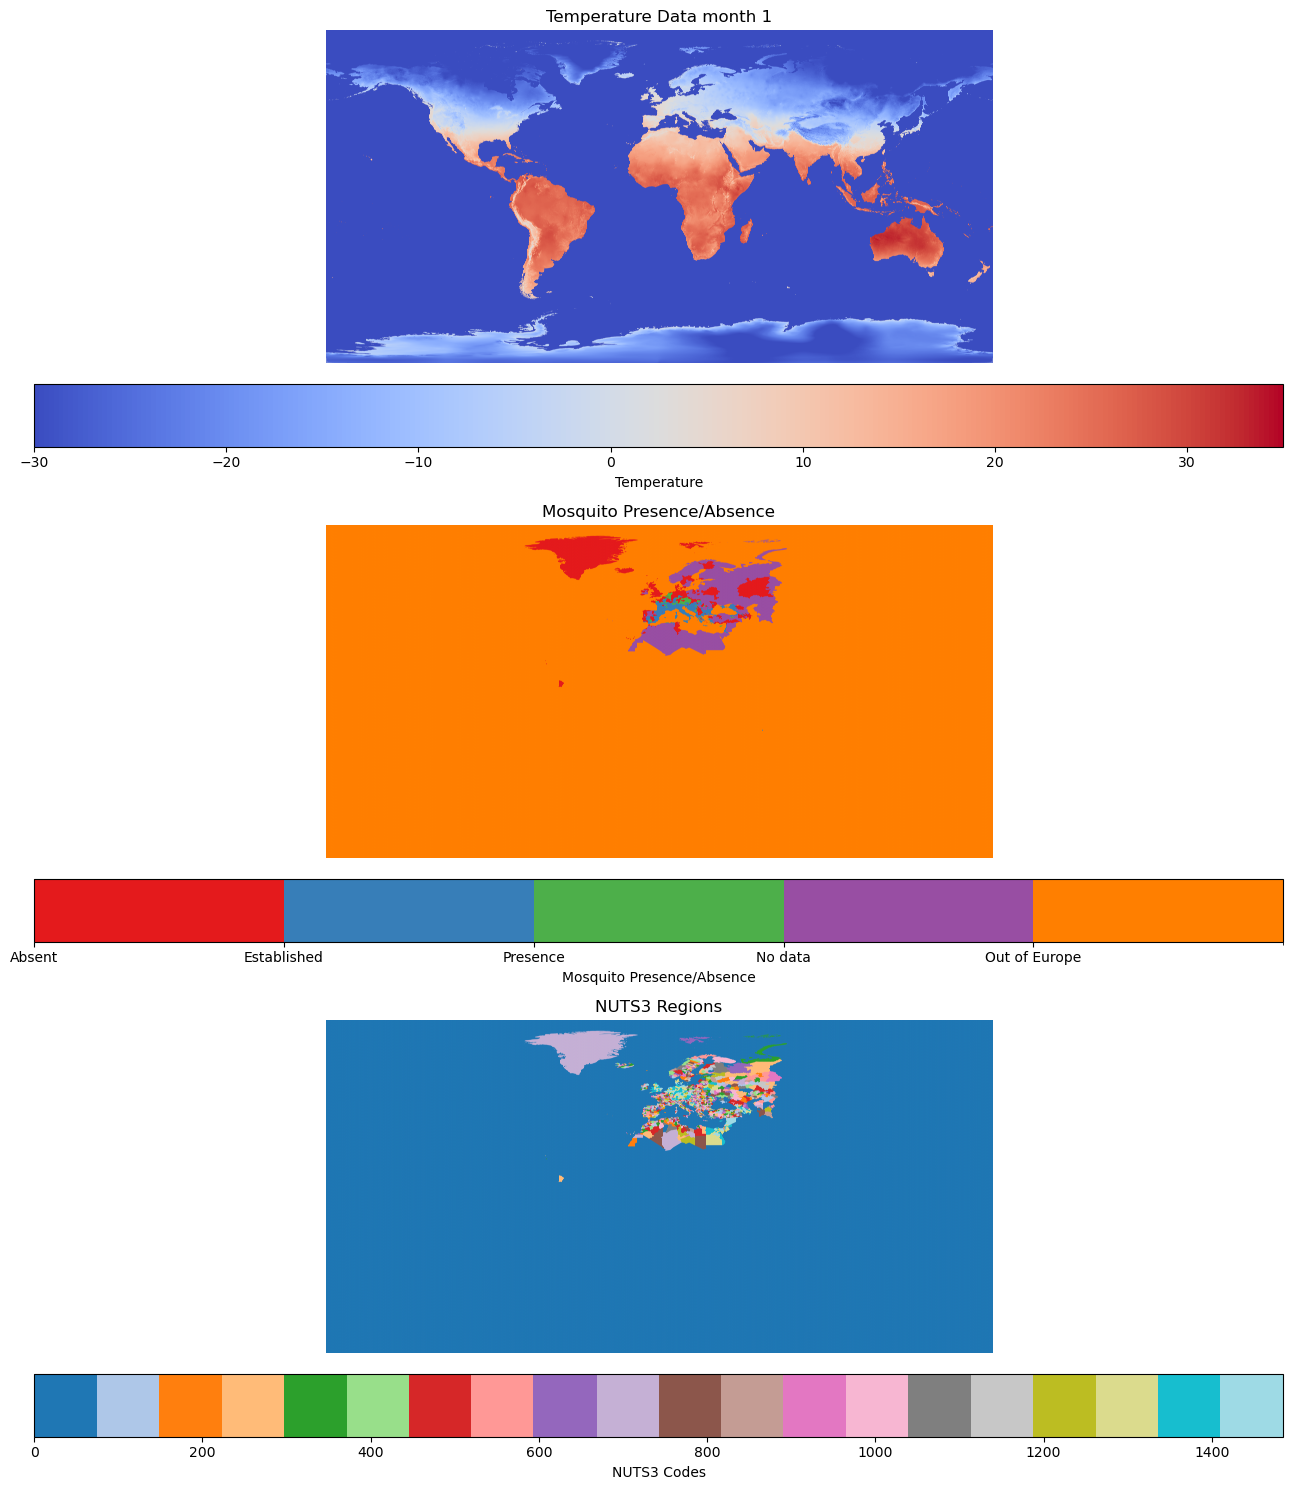

In [46]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Open all three rasters
with rasterio.open(raster_file) as temp_src, \
     rasterio.open(parent_dir + 'albopictus_ecdc_as_WorldClim_raster.tif') as mosq_src, \
     rasterio.open(parent_dir + 'albopictus_ecdc_NUTS3_location_codes.tif') as nuts_src:

    temp_data = temp_src.read(1)
    mosq_data = mosq_src.read(1)
    nuts_data = nuts_src.read(1)

fig, axs = plt.subplots(3, 1, figsize=(20, 15))

# Temperature Data Plot
temp_plot = axs[0].imshow(temp_data, cmap='coolwarm', vmin=-30, vmax=35)
axs[0].set_title('Temperature Data month 1')
axs[0].axis('off')
plt.colorbar(temp_plot, ax=axs[0], orientation='horizontal', pad=0.05, label='Temperature')

# Mosquito Presence Data Plot
cmap_mosq = mcolors.ListedColormap(['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'])
bounds_mosq = [0, 1, 2, 3, 4, 5]
norm_mosq = mcolors.BoundaryNorm(bounds_mosq, cmap_mosq.N)
mosq_plot = axs[1].imshow(mosq_data, cmap=cmap_mosq, norm=norm_mosq)
axs[1].set_title('Mosquito Presence/Absence')
axs[1].axis('off')
cbar_mosq = plt.colorbar(mosq_plot, ax=axs[1], orientation='horizontal', pad=0.05, ticks=bounds_mosq[:-1])
cbar_mosq.ax.set_xticklabels(['Absent', 'Established', 'Presence', 'No data', 'Out of Europe'])
cbar_mosq.set_label('Mosquito Presence/Absence')

# NUTS3 Code Plot
# Define a color map for NUTS3 codes, using 'tab20' for distinct regions
cmap_nuts = plt.get_cmap('tab20', len(np.unique(nuts_data)))
nuts_plot = axs[2].imshow(nuts_data, cmap=cmap_nuts)
axs[2].set_title('NUTS3 Regions')
axs[2].axis('off')
cbar_nuts = plt.colorbar(nuts_plot, ax=axs[2], orientation='horizontal', pad=0.05)
cbar_nuts.set_label('NUTS3 Codes')

plt.tight_layout()
plt.savefig('mosquito_presence_absence_nuts3.png', dpi=300)
plt.show()
